# Performance Analysis - Study 2b

## Loading the libraries

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import pandas_datareader.data as web
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import itertools
from scipy import stats

## Loading the data

In [2]:
df = pd.read_csv('./data/ageRisk_long.csv', index_col=0)

## Fetching performance data & calculating performance measures

In [3]:
start_date = '2023-07-01'
end_date = '2024-01-01' # we calculate the performance over the 6 month following the financial advice data collection
market_data = {}

def fetch_risk_free_rate():
    risk_free_data = web.DataReader("DGS10", "fred").loc[start_date:end_date]
    risk_free_rate = risk_free_data.mean() / 100
    risk_free_rate = risk_free_rate['DGS10']
    return risk_free_rate
    
risk_free_rate = fetch_risk_free_rate()

In [ ]:
def calculate_sharpe_ratio(row):
    if (row['portfolio_std_dev'] == 0) & (row['portfolio_return'] == 0):
        return np.nan
    sharpe = (row['portfolio_return'] - risk_free_rate) / row['portfolio_std_dev']
    return sharpe

def get_market_data(tickers):
    for ticker in tickers:
        try:
            prices = yf.download(ticker, start=start_date, end=end_date)['Adj Close']
            market_data[ticker] = prices
        except:
            market_data[ticker] = pd.Series([1 for _ in range(len(market_data[next(iter(market_data))]))], 
                                              index=market_data[next(iter(market_data))].index) 

def get_portfolio_data(df, group_cols):
    get_market_data(df['ticker_symbol'].dropna().unique())
    portfolio_df = pd.DataFrame(columns=['ai', 'age', 'risk-taking', 'cond', 'iteration', 'portfolio_return', 'portfolio_std_dev'])
    df = df[~df['amount_to_invest'].isnull()] # exclude rows with no investment from financial advice
    grouped = df.groupby(group_cols)
    
    for name, group in grouped:
        total_investment = group['amount_to_invest'].sum()
        weights = group['amount_to_invest'] / total_investment
        prices_df = pd.DataFrame()
        for i, ticker in enumerate(group['ticker_symbol']):
            if ticker in market_data:
                prices_df[ticker] = market_data[ticker]
            else:
                # Assume no return and no standard deviation for invalid/ Nan tickers
                prices_df[f'{ticker}_{i}'] = pd.Series([1 for _ in range(len(market_data[next(iter(market_data))]))], 
                                              index=market_data[next(iter(market_data))].index)
            
        prices_df = prices_df.ffill().bfill().fillna(1) # fill the price value for equities on the weekend with the last price for portfolios with cryptos 

        # Calculate the cumulative portfolio return
        cumulative_returns = (prices_df.iloc[-1] / prices_df.iloc[0]) - 1
        weights.index = cumulative_returns.index
        portfolio_return = (cumulative_returns * weights).sum()

        # Calculate the portfolio volatilty
        returns_df = prices_df.pct_change()
        cov_matrix = returns_df.cov()
        portfolio_variance = np.dot(weights.T, np.dot(cov_matrix, weights))
        portfolio_std_dev = np.sqrt(portfolio_variance)
        if np.isnan(portfolio_std_dev):
            print(f'{name}')
            print(f'{weights}')
            print(f'prices: {prices_df}')
            print(f'returns_df: {returns_df}')
        portfolio_df.loc[len(portfolio_df)] = {
            'ai': name[0],
            'age': name[1],
            'risk-taking': name[2],
            'cond': name[3],
            'iteration': name[4],
            'portfolio_return': portfolio_return,
            'portfolio_std_dev': portfolio_std_dev
        }
    return portfolio_df
        
group_cols = ['ai', 'age', 'risk-taking', 'cond', 'iteration']    
portfolio_df = get_portfolio_data(df, group_cols)
portfolio_df['sharpe'] = portfolio_df.apply(calculate_sharpe_ratio, axis=1)
portfolio_df.to_csv('./data/performance_features.csv')


## Analysis

In [4]:
portfolio_df = pd.read_csv('./data/performance_features.csv', index_col=0)
portfolio_df['risk-taking'] = portfolio_df['risk-taking'].replace({'averse':'low', 'neutral':'medium', 'seeking':'high'})
portfolio_df['cond'] = portfolio_df['cond'].replace({'control':'Control prompt', 'engineered':'Debiased prompt'})
portfolio_df['portfolio_std_dev'] *= 100 # in %
portfolio_df['portfolio_return'] *= 100 # in %

In [5]:
label_dict = {'cond':'Condition', 'age':'Age', 'risk-taking':'Risk Tendency'}

def fetch_benchmark_data(ticker):
    prices = yf.download(ticker, start=start_date, end=end_date)['Adj Close']
    cumulative_return = (prices.iloc[-1] / prices.iloc[0]) - 1
    returns_df = prices.pct_change()
    std_dev = returns_df.std()
    sharpe = (cumulative_return - risk_free_rate) / std_dev
    return cumulative_return, std_dev, sharpe

def show_anova(df, column, group1, group2=None):
    if group1 and group2:
        df['label'] = df.apply(lambda row: f"({row[group1]}, {row[group2]})", axis=1)
    else:
        df['label'] = df[group1]
        
    model = ols(f'{column} ~ label', data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(anova_table)
    tukey_results = pairwise_tukeyhsd(endog=df[column], groups=df['label'], alpha=0.05)
    print(tukey_results)

def show_ttest(raw, column, groups, benchmark):
    for group_name, group_data in raw.groupby(groups, observed=False):
        group_values = group_data[column]
        t_statistic, p_value = stats.ttest_1samp(group_values, benchmark)
        print(f'group: {group_name} got t: {t_statistic} p_value: {round(p_value,4)} dfs: {len(group_values)-1} benchmark: {round(benchmark, 4)}')
    
def show_mean_errplot(raw, column, label, benchmark, benchmark_label, group1, group2=None):
    show_anova(raw, column, group1, group2)

    if group1 == 'risk-taking':
        order = ['low', 'medium', 'high']
        raw[group1] = pd.Categorical(raw[group1], categories=order, ordered=True)
        raw.sort_values(by=group1, inplace=True)
    
    groups = [group1, group2] if group2 != None else [group1]
    show_ttest(raw, column, groups, benchmark)
    
    grouped = raw.groupby(groups, observed=False)[column]
    if len(groups) > 1:
        means = grouped.mean().unstack()
        std_devs = grouped.std().unstack()
        sample_sizes = grouped.count().unstack()
    else:
        means = grouped.mean()
        std_devs = grouped.std()
        sample_sizes = grouped.count()

    standard_errors = std_devs / np.sqrt(sample_sizes)

    print(f'means:\n{round(means, 4)}')
    print(f'stds:\n{round(std_devs,4)}')
    print(sample_sizes)

    colors = ['darkgray']
    if group2:
        colors = ['dimgray', 'darkgray', 'lightgray']
    ax = means.plot(kind='bar', stacked=False, yerr=standard_errors.values.T, capsize=5, figsize=(5, 4), color=colors, zorder=2)
    ax.axhline(y=benchmark, color='black', linestyle='--', zorder=4)
    ax.text(1.02, benchmark, benchmark_label, va='center', ha="left", bbox=dict(facecolor='none', edgecolor='none', boxstyle='round,pad=0.2'), transform=ax.get_yaxis_transform())

    ax.set_ylabel(label)
    ax.set_xticklabels(means.index, rotation=0, ha='center')
    group1 = label_dict.get(group1, group1)
    ax.set_xlabel(group1)
    ax.grid(True, zorder=1)
    
    if group2:
        group2 = label_dict.get(group2, group2) 
        legend = ax.legend(title=group2)
        legend.get_title().set_text(group2)

    group2_label = f'-{group2}' if group2 != None else ''
    plt.savefig(f'./figures/performance/{group1}{group2_label}-{label}.png', bbox_inches='tight')
    
    plt.tight_layout()
    plt.show()
    

In [6]:
benchmark_return, benchmark_std, benchmark_sharpe = fetch_benchmark_data('VT')
benchmark_return *= 100 # in %
benchmark_std *= 100 # in %

[*********************100%%**********************]  1 of 1 completed


### Portfolio Return

               sum_sq     df         F   PR(>F)
label       16.942010    1.0  1.347785  0.24722
Residual  2237.507323  178.0       NaN      NaN
        Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1          group2     meandiff p-adj   lower  upper  reject
--------------------------------------------------------------------
Control prompt Debiased prompt  -0.6136 0.2472 -1.6566 0.4294  False
--------------------------------------------------------------------
group: ('Control prompt',) got t: -0.4153650891041727 p_value: 0.6789 dfs: 89 benchmark: 7.0324
group: ('Debiased prompt',) got t: -2.3807618732147366 p_value: 0.0194 dfs: 89 benchmark: 7.0324
means:
cond
Control prompt     6.8609
Debiased prompt    6.2473
Name: portfolio_return, dtype: float64
stds:
cond
Control prompt     3.9182
Debiased prompt    3.1286
Name: portfolio_return, dtype: float64
cond
Control prompt     90
Debiased prompt    90
Name: portfolio_return, dtype: int64


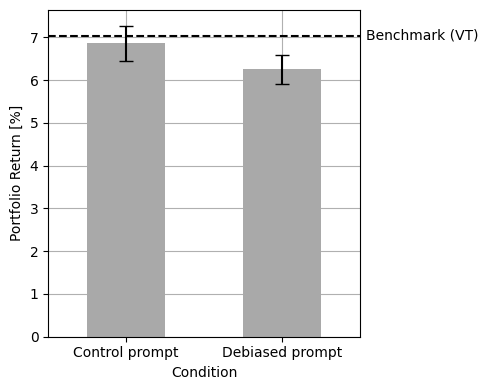

In [7]:
show_mean_errplot(portfolio_df, 'portfolio_return', 'Portfolio Return [%]', benchmark_return, 'Benchmark (VT)', 'cond')

               sum_sq     df          F    PR(>F)
label      290.388100    2.0  13.084799  0.000005
Residual  1964.061233  177.0        NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  high    low  -2.7272    0.0 -4.1647 -1.2897   True
  high medium  -0.0669 0.9934 -1.5044  1.3706  False
   low medium   2.6603 0.0001  1.2228  4.0978   True
----------------------------------------------------
group: ('low',) got t: -12.884456400940714 p_value: 0.0 dfs: 59 benchmark: 7.0324
group: ('medium',) got t: 1.0826349662788102 p_value: 0.2834 dfs: 59 benchmark: 7.0324
group: ('high',) got t: 0.7194645247341975 p_value: 0.4747 dfs: 59 benchmark: 7.0324
means:
risk-taking
low       4.7583
medium    7.4186
high      7.4854
Name: portfolio_return, dtype: float64
stds:
risk-taking
low       1.3672
medium    2.7628
high      4.8772
Name: portfolio_return, dtype: float64
risk-tak

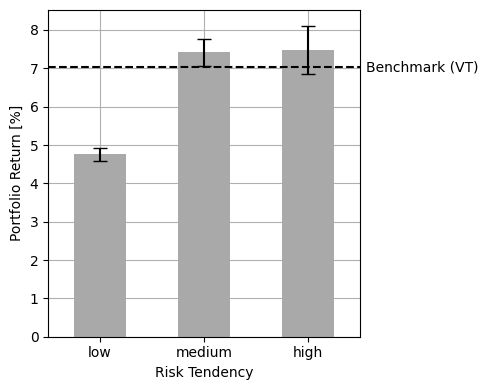

In [8]:
show_mean_errplot(portfolio_df, 'portfolio_return', 'Portfolio Return [%]',  benchmark_return, 'Benchmark (VT)', 'risk-taking')

               sum_sq     df         F    PR(>F)
label        0.887089    1.0  0.070068  0.791544
Residual  2253.562244  178.0       NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    15     30  -0.0235 0.9993 -1.5632 1.5163  False
    15     50  -0.1668 0.9645 -1.7066 1.3729  False
    30     50  -0.1434 0.9737 -1.6831 1.3964  False
---------------------------------------------------
group: (15,) got t: -0.8902386413977696 p_value: 0.377 dfs: 59 benchmark: 7.0324
group: (30,) got t: -0.8678248851475322 p_value: 0.389 dfs: 59 benchmark: 7.0324
group: (50,) got t: -1.4357411766295496 p_value: 0.1564 dfs: 59 benchmark: 7.0324
means:
age
15    6.6175
30    6.5940
50    6.4507
Name: portfolio_return, dtype: float64
stds:
age
15    3.6101
30    3.9129
50    3.1386
Name: portfolio_return, dtype: float64
age
15    60
30    60
50    60
Name: portfolio_return, dtype: int64


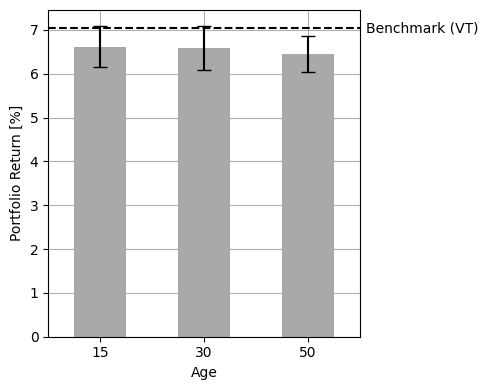

In [9]:
show_mean_errplot(portfolio_df, 'portfolio_return', 'Portfolio Return [%]', benchmark_return, 'Benchmark (VT)', 'age')

               sum_sq     df         F    PR(>F)
label      383.550049    5.0  7.134292  0.000004
Residual  1870.899284  174.0       NaN       NaN
                   Multiple Comparison of Means - Tukey HSD, FWER=0.05                   
         group1                    group2          meandiff p-adj   lower   upper  reject
-----------------------------------------------------------------------------------------
  (Control prompt, high)     (Control prompt, low)  -3.2946 0.0019 -5.7345 -0.8548   True
  (Control prompt, high)  (Control prompt, medium)   0.9394 0.8769 -1.5005  3.3792  False
  (Control prompt, high)   (Debiased prompt, high)  -0.3211  0.999 -2.7609  2.1188  False
  (Control prompt, high)    (Debiased prompt, low)  -2.4808 0.0438 -4.9206  -0.041   True
  (Control prompt, high) (Debiased prompt, medium)  -1.3942 0.5689  -3.834  1.0457  False
   (Control prompt, low)  (Control prompt, medium)    4.234    0.0  1.7942  6.6738   True
   (Control prompt, low)   (Debiased prompt

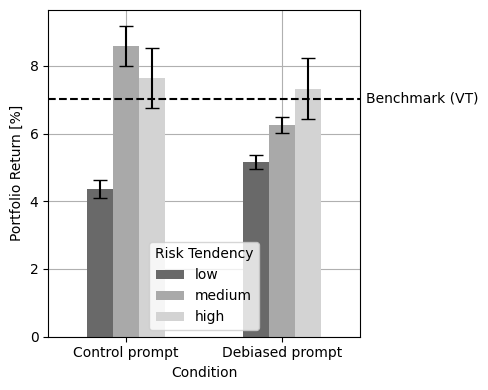

In [10]:
show_mean_errplot(portfolio_df, 'portfolio_return', 'Portfolio Return [%]', benchmark_return, 'Benchmark (VT)', 'cond', 'risk-taking')

### Portfolio Volatility

             sum_sq     df          F    PR(>F)
label      2.355810    1.0  11.828677  0.000726
Residual  35.450636  178.0        NaN       NaN
         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1          group2     meandiff p-adj   lower   upper  reject
---------------------------------------------------------------------
Control prompt Debiased prompt  -0.2288 0.0007 -0.3601 -0.0975   True
---------------------------------------------------------------------
group: ('Control prompt',) got t: 5.258625923241286 p_value: 0.0 dfs: 89 benchmark: 0.7562
group: ('Debiased prompt',) got t: 1.5907069414448824 p_value: 0.1152 dfs: 89 benchmark: 0.7562
means:
cond
Control prompt     1.0448
Debiased prompt    0.8160
Name: portfolio_std_dev, dtype: float64
stds:
cond
Control prompt     0.5207
Debiased prompt    0.3567
Name: portfolio_std_dev, dtype: float64
cond
Control prompt     90
Debiased prompt    90
Name: portfolio_std_dev, dtype: int64


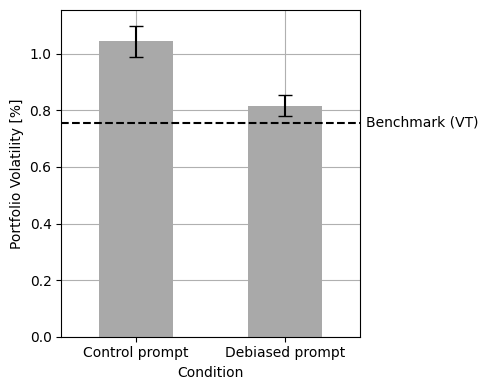

In [11]:
show_mean_errplot(portfolio_df, 'portfolio_std_dev', 'Portfolio Volatility [%]', benchmark_std, 'Benchmark (VT)', 'cond')

             sum_sq     df           F        PR(>F)
label     20.670712    2.0  106.756906  3.853123e-31
Residual  17.135734  177.0         NaN           NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
  high    low  -0.8137   0.0 -0.9479 -0.6794   True
  high medium  -0.5491   0.0 -0.6833 -0.4148   True
   low medium   0.2646   0.0  0.1303  0.3989   True
---------------------------------------------------
group: ('low',) got t: -18.539455009748266 p_value: 0.0 dfs: 59 benchmark: 0.7562
group: ('medium',) got t: 2.9526517655913582 p_value: 0.0045 dfs: 59 benchmark: 0.7562
group: ('high',) got t: 9.914630805443316 p_value: 0.0 dfs: 59 benchmark: 0.7562
means:
risk-taking
low       0.5710
medium    0.8356
high      1.3846
Name: portfolio_std_dev, dtype: float64
stds:
risk-taking
low       0.0774
medium    0.2083
high      0.4910
Name: portfolio_std_dev, dtype: float64
risk-tak

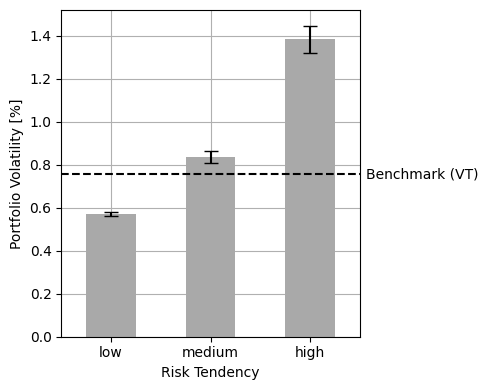

In [12]:
show_mean_errplot(portfolio_df, 'portfolio_std_dev', 'Portfolio Volatility [%]', benchmark_std, 'Benchmark (VT)', 'risk-taking')

             sum_sq     df         F    PR(>F)
label      0.411806    1.0  1.960212  0.163231
Residual  37.394640  178.0       NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    15     30  -0.0265 0.9466 -0.2248 0.1718  False
    15     50  -0.1146 0.3608 -0.3129 0.0837  False
    30     50  -0.0881 0.5461 -0.2864 0.1102  False
---------------------------------------------------
group: (15,) got t: 3.8402199686492646 p_value: 0.0003 dfs: 59 benchmark: 0.7562
group: (30,) got t: 3.231813895441146 p_value: 0.002 dfs: 59 benchmark: 0.7562
group: (50,) got t: 1.7753608016119486 p_value: 0.081 dfs: 59 benchmark: 0.7562
means:
age
15    0.9774
30    0.9509
50    0.8628
Name: portfolio_std_dev, dtype: float64
stds:
age
15    0.4463
30    0.4668
50    0.4652
Name: portfolio_std_dev, dtype: float64
age
15    60
30    60
50    60
Name: portfolio_std_dev, dtype: int64


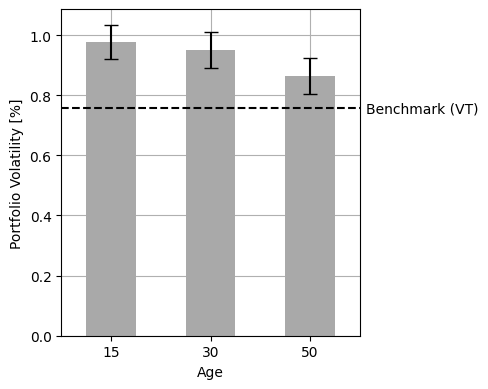

In [13]:
show_mean_errplot(portfolio_df, 'portfolio_std_dev', 'Portfolio Volatility [%]', benchmark_std, 'Benchmark (VT)', 'age')

             sum_sq     df          F        PR(>F)
label     24.936124    5.0  67.424662  6.511647e-39
Residual  12.870322  174.0        NaN           NaN
                   Multiple Comparison of Means - Tukey HSD, FWER=0.05                   
         group1                    group2          meandiff p-adj   lower   upper  reject
-----------------------------------------------------------------------------------------
  (Control prompt, high)     (Control prompt, low)  -1.0659    0.0 -1.2683 -0.8635   True
  (Control prompt, high)  (Control prompt, medium)  -0.6704    0.0 -0.8727  -0.468   True
  (Control prompt, high)   (Debiased prompt, high)  -0.4778    0.0 -0.6802 -0.2755   True
  (Control prompt, high)    (Debiased prompt, low)  -1.0393    0.0 -1.2416 -0.8369   True
  (Control prompt, high) (Debiased prompt, medium)  -0.9056    0.0 -1.1079 -0.7032   True
   (Control prompt, low)  (Control prompt, medium)   0.3955    0.0  0.1932  0.5979   True
   (Control prompt, low)   (Debias

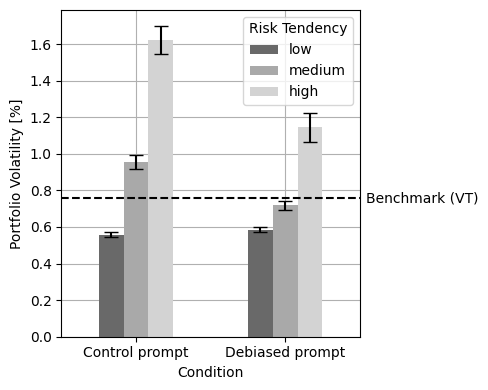

In [14]:
show_mean_errplot(portfolio_df, 'portfolio_std_dev', 'Portfolio Volatility [%]', benchmark_std, 'Benchmark (VT)', 'cond', 'risk-taking')

### Sharpe

In [15]:
print(portfolio_df.shape)
sharpe_df = portfolio_df.copy()
sharpe_df = sharpe_df.dropna()
print(sharpe_df.shape)

(180, 9)
(180, 9)


               sum_sq     df         F    PR(>F)
label        1.103677    1.0  0.102498  0.749227
Residual  1916.661869  178.0       NaN       NaN
        Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1          group2     meandiff p-adj   lower  upper  reject
--------------------------------------------------------------------
Control prompt Debiased prompt   0.1566 0.7492 -0.8087 1.1219  False
--------------------------------------------------------------------
group: ('Control prompt',) got t: -3.5652052194335933 p_value: 0.0006 dfs: 89 benchmark: 3.6172
group: ('Debiased prompt',) got t: -3.7854509344287535 p_value: 0.0003 dfs: 89 benchmark: 3.6172
means:
cond
Control prompt     2.2765
Debiased prompt    2.4331
Name: sharpe, dtype: float64
stds:
cond
Control prompt     3.5677
Debiased prompt    2.9677
Name: sharpe, dtype: float64
cond
Control prompt     90
Debiased prompt    90
Name: sharpe, dtype: int64


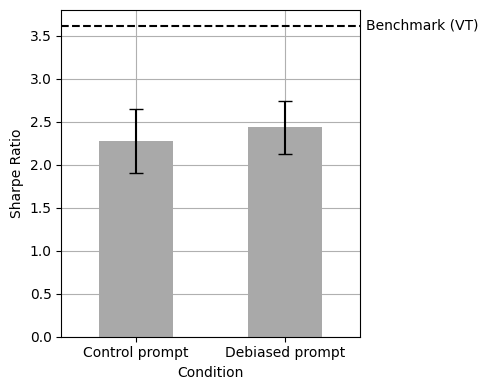

In [16]:
show_mean_errplot(sharpe_df, 'sharpe', 'Sharpe Ratio', benchmark_sharpe, 'Benchmark (VT)', 'cond')

               sum_sq     df          F        PR(>F)
label      278.527300    2.0  15.037269  9.298676e-07
Residual  1639.238247  177.0        NaN           NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  high    low  -2.2278 0.0003  -3.541 -0.9145   True
  high medium   0.6864  0.434 -0.6269  1.9996  False
   low medium   2.9141    0.0  1.6009  4.2274   True
----------------------------------------------------
group: ('low',) got t: -9.581007643537784 p_value: 0.0 dfs: 59 benchmark: 3.6172
group: ('medium',) got t: -0.17741747421123027 p_value: 0.8598 dfs: 59 benchmark: 3.6172
group: ('high',) got t: -1.517856631635722 p_value: 0.1344 dfs: 59 benchmark: 3.6172
means:
risk-taking
low       0.6408
medium    3.5549
high      2.8686
Name: sharpe, dtype: float64
stds:
risk-taking
low       2.4064
medium    2.7196
high      3.8206
Name: sharpe, dtype: float64
risk-taking
low

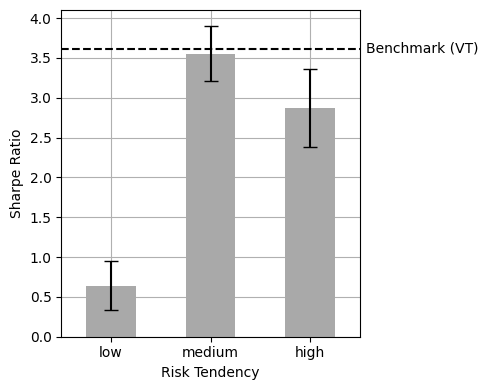

In [17]:
show_mean_errplot(sharpe_df, 'sharpe', 'Sharpe Ratio', benchmark_sharpe, 'Benchmark (VT)', 'risk-taking')

               sum_sq     df         F    PR(>F)
label        0.037158    1.0  0.003449  0.953235
Residual  1917.728388  178.0       NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    15     30   0.0882 0.9882 -1.3321 1.5085  False
    15     50  -0.0257  0.999  -1.446 1.3946  False
    30     50  -0.1139 0.9804 -1.5342 1.3064  False
---------------------------------------------------
group: (15,) got t: -3.1501381357692475 p_value: 0.0026 dfs: 59 benchmark: 3.6172
group: (30,) got t: -2.699881636961353 p_value: 0.009 dfs: 59 benchmark: 3.6172
group: (50,) got t: -3.087657490979564 p_value: 0.0031 dfs: 59 benchmark: 3.6172
means:
age
15    2.3339
30    2.4222
50    2.3082
Name: sharpe, dtype: float64
stds:
age
15    3.1556
30    3.4287
50    3.2839
Name: sharpe, dtype: float64
age
15    60
30    60
50    60
Name: sharpe, dtype: int64


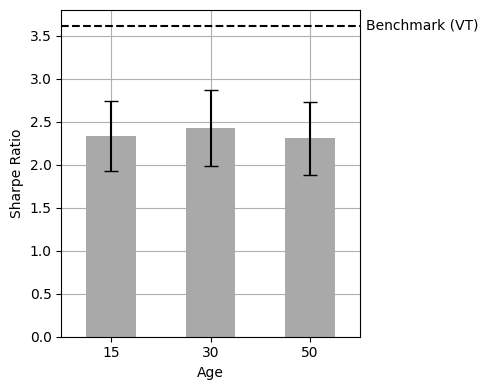

In [18]:
show_mean_errplot(sharpe_df, 'sharpe', 'Sharpe Ratio', benchmark_sharpe, 'Benchmark (VT)', 'age')

               sum_sq     df         F        PR(>F)
label      374.559178    5.0  8.446478  3.554834e-07
Residual  1543.206368  174.0       NaN           NaN
                   Multiple Comparison of Means - Tukey HSD, FWER=0.05                   
         group1                    group2          meandiff p-adj   lower   upper  reject
-----------------------------------------------------------------------------------------
  (Control prompt, high)     (Control prompt, low)  -2.3752 0.0279 -4.5911 -0.1593   True
  (Control prompt, high)  (Control prompt, medium)   2.1479 0.0633  -0.068  4.3638  False
  (Control prompt, high)   (Debiased prompt, high)   1.0327 0.7606 -1.1832  3.2486  False
  (Control prompt, high)    (Debiased prompt, low)  -1.0477 0.7493 -3.2636  1.1682  False
  (Control prompt, high) (Debiased prompt, medium)   0.2575 0.9994 -1.9583  2.4734  False
   (Control prompt, low)  (Control prompt, medium)   4.5231    0.0  2.3072  6.7389   True
   (Control prompt, low)   (Deb

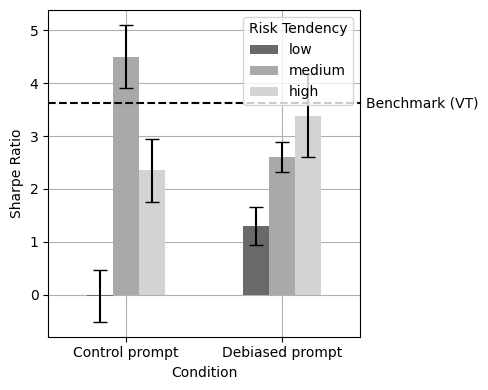

In [19]:
show_mean_errplot(sharpe_df, 'sharpe', 'Sharpe Ratio', benchmark_sharpe, 'Benchmark (VT)', 'cond', 'risk-taking')